# 0. Import libraries


In [1]:
import requests
import json
import pandas as pd
import time
from tqdm import tqdm
from bs4 import BeautifulSoup

In [2]:
# Define the API endpoint and polite defaults
API_URL = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "MediaWikiAPITutorial/1.0 (contact: your.email@example.com)"
REQUEST_DELAY = 0.5  # seconds between requests
TIMEOUT = 30

session = requests.Session()
session.headers.update({"User-Agent": USER_AGENT})

def api_get(params: dict) -> dict | None:
    """Make a safe request to the MediaWiki API with retries and rate limiting."""
    try:
        response = session.get(API_URL, params=params, timeout=TIMEOUT)
        response.raise_for_status()
        data = response.json()
    except requests.exceptions.RequestException as e:
        print(f"Request error: {e}")
        return None
    except json.JSONDecodeError:
        print("Response was not valid JSON")
        return None
    finally:
        time.sleep(REQUEST_DELAY)

    return data

# 1. Get leaders

In [3]:
df = pd.read_csv("../data/world_leaders.csv")

df['wikidata_id'] = None
df['gender'] = None

df.head()

,person,position,country,wikidata_id,gender
0,Hibatullah Akhundzada,Supreme Leader,Afghanistan,None,None
1,Edi Rama,Prime Minister,Albania,None,None
2,Abdelmadjid Tebboune,President,Algeria,None,None
3,Xavier Espot,Prime Minister,Andorra,None,None
4,João Lourenço,President,Angola,None,None


# 2. Get wikidataID

In [4]:
def get_wikidata_id(title):
    """
    Retrieve the Wikidata ID (e.g., Qxxxx) of a Wikipedia article.

    Parameters:
    title (str): Wikipedia article title

    Returns:
    str: Wikidata ID or None if not found
    """
    params = {
        'action': 'query',
        'format': 'json',
        'titles': title,
        'prop': 'pageprops',  #
        'ppprop':'wikibase_item',  # Get the Wikidata ID
        "format":"json"
    }
    
    try:
        data = api_get(params)
        pages = data["query"]["pages"]
        page = next(iter(pages.values()))
        return page.get("pageprops", {}).get("wikibase_item")

    except Exception:
        return None
    

# Example: Get Wikidata ID for "Judith Suminwa"
get_wikidata_id("Judith Suminwa")

'Q117472023'

# 3. get gender

In [5]:
def get_gender(qid):

    url = f"https://www.wikidata.org/wiki/Special:EntityData/{qid}.json"

    gender_cat = {
        "Q6581097": "male",
        "Q6581072": "female"
    }

    try:
        r = session.get(url)
        data = r.json()
        gender_qid = data["entities"][qid]["claims"]["P21"][0]["mainsnak"]["datavalue"]["value"]["id"]
        return gender_cat.get(gender_qid, "other")

    except:
        return None

# 4. Get full dataset with wikidata id and gender

In [6]:
for idx, row in tqdm(df.iterrows(), total=len(df)):
    person_name = row['person']
    
    try:
        qid = get_wikidata_id(person_name)
        df.at[idx, 'wikidata_id'] = qid
        if qid:
            gender = get_gender(qid)
            df.at[idx, 'gender'] = gender
    except Exception as e:
        print(f"Error processing {person_name}: {e}")

100%|██████████| 220/220 [03:47<00:00,  1.04s/it]


In [15]:
# check missing values
df.isnull().sum()

# drop rows with missing wikidata_id and gender
df = df.dropna(subset=['wikidata_id', 'gender'])

df

# save the updated dataframe to a new CSV file
df.to_csv("../data/world_leaders_with_gender_wikidataid.csv", index=False)

# 6. Visualization

In [10]:
# statistics summary
df['gender'].value_counts()

gender
male      181
female     26
Name: count, dtype: int64

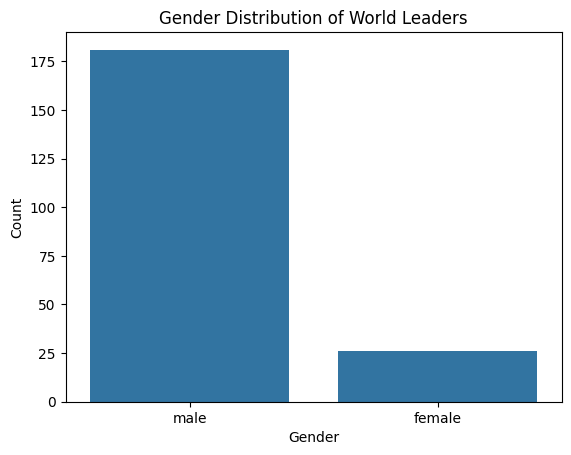

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# bar plot of gender distribution
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution of World Leaders')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

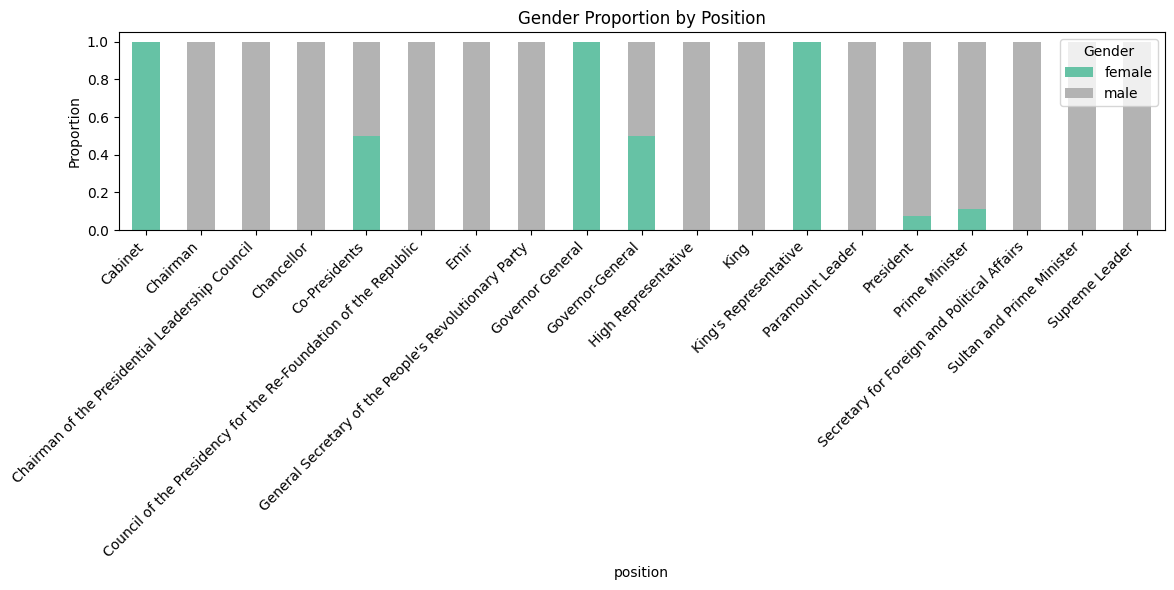

In [ ]:
# gender distribution by position

gender_position = df.groupby(['position', 'gender']).size().unstack(fill_value=0)

gender_position_pct = gender_position.div(gender_position.sum(axis=1), axis=0)

gender_position_pct.plot(kind='bar', stacked=True, figsize=(12,6), colormap="Set2")
plt.ylabel("Proportion")
plt.title("Gender Proportion by Position")
plt.legend(title="Gender")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()